# Tourism Analytic Project

## Project Introduction

* Tourism is one of the most important global industries, generating large amounts of data from travelers around the world. This project focuses on analyzing tourist visit behavior by combining data related to users, locations, attractions, travel modes, and user ratings.

* In this project, multiple datasets were merged to create one comprehensive dataset that represents how users travel, where they go, what attractions they visit, and how they rate their experiences. Each record in the final dataset represents a single visit by a user to a specific attraction at a given time.

* The final dataset is suitable for data analysis, visualization, and machine learning applications, and the notebook is written with clear explanations so that both technical and non-technical users can understand the insights derived from the data.

### Author - Priyanka Kushwaha

## Github link
https://github.com/Priyanka-kushwaha90/AI-ML-Projects

# Step-1.   Dataset Loading and Merging
In this step, I imported the necessary Python libraries such as Pandas to manage and analyze the data efficiently. Multiple tourism-related datasets were then loaded into Pandas DataFrames using appropriate file-reading functions. After loading, the datasets were reviewed by checking their structure, column names, and size to ensure that the data was imported correctly and was ready for further processing.

Then multiple datasets were combined into a single, unified dataset to create a complete view of the tourism data. The merging process was carried out using common identifier columns such as User ID, City ID, Region ID, and Visit Mode ID.

In [1]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
city=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/City.csv")
city.columns
city.shape

(9143, 3)

In [3]:
country=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Countrys.csv")
country.columns
country.shape

(165, 3)

In [4]:
merge_df =pd.merge(city,country, on='CountryId', how='left')
merge_df.columns

Index(['CityId', 'CityName', 'CountryId', 'Country', 'RegionId'], dtype='object')

In [5]:
region=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Regions.csv")
region.columns

Index(['Region', 'RegionId', 'ContinentId'], dtype='object')

In [6]:
region.isnull().sum()

Region         977
RegionId       977
ContinentId    977
dtype: int64

In [7]:
region_clean = region.dropna(subset=['RegionId'])


In [8]:
#Remove duplicates
region_clean = region_clean.drop_duplicates(subset=['RegionId'])

# reset index
region_clean = region_clean.reset_index(drop=True)

region_clean['RegionId'].is_unique
region_clean.shape

(22, 3)

In [9]:
merge_df2=pd.merge(merge_df,region_clean, on ='RegionId' , how='left')
merge_df2.columns

Index(['CityId', 'CityName', 'CountryId', 'Country', 'RegionId', 'Region',
       'ContinentId'],
      dtype='object')

In [10]:
continent=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Continents.csv")
continent.columns


Index(['ContinentId', 'Continent'], dtype='object')

In [11]:
continent_clean = continent.dropna(subset=['ContinentId'])

# reset index
continent_clean = continent_clean.reset_index(drop=True)

continent_clean['ContinentId'].is_unique

True

In [12]:
merge_df3=pd.merge(merge_df2,continent_clean, on ='ContinentId', how='left')
merge_df3

,CityId,CityName,CountryId,Country,RegionId,Region,ContinentId,Continent
0,0,-,0,-,0,-,0.0,-
1,1,Douala,1,Cameroon,1,Central Africa,1.0,Africa
2,2,South Region,1,Cameroon,1,Central Africa,1.0,Africa
3,3,N'Djamena,2,Chad,1,Central Africa,1.0,Africa
4,4,Kigali,3,Rwanda,1,Central Africa,1.0,Africa
...,...,...,...,...,...,...,...,...
9138,9138,Yeovil,163,United Kingdom,21,Western Europe,5.0,Europe
9139,9139,York,163,United Kingdom,21,Western Europe,5.0,Europe
9140,9140,Yorkshire,163,United Kingdom,21,Western Europe,5.0,Europe
9141,9141,Zaandam,163,United Kingdom,21,Western Europe,5.0,Europe


In [13]:
user=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Users.csv")
user.columns


Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')

In [14]:
transaction=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Transactions.csv")
transaction.columns


Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')

In [15]:
merge_df4 =pd.merge(transaction,user, on='UserId', how='left')
merge_df4.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId',
       'CityId'],
      dtype='object')

In [16]:
items=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Items.csv")
items.columns

Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')

In [17]:
merge_df5= pd.merge(merge_df4,items, on ='AttractionId' ,how='left')
merge_df5.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId',
       'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')

In [18]:
type=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Types.csv")
type.columns

Index(['AttractionTypeId', 'AttractionType'], dtype='object')

In [19]:
merge_df6=pd.merge(merge_df5,type, on ='AttractionTypeId', how='left')
merge_df6.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId',
       'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'AttractionType'],
      dtype='object')

In [20]:
merge_df6 = merge_df6.loc[:, ~merge_df6.columns.str.contains(
    'country|region|continent', case=False
)]


In [21]:
merge_df6.columns


Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'CityId', 'AttractionCityId',
       'AttractionTypeId', 'Attraction', 'AttractionAddress',
       'AttractionType'],
      dtype='object')

In [22]:
final_df=pd.merge(merge_df6,merge_df3, on ='CityId' , how='left')


In [23]:
mode=pd.read_csv("C:/Users/kushw/Downloads/tourism project data/Modes.csv")
mode.columns

Index(['VisitModeId', 'VisitMode'], dtype='object')

In [24]:
import pandas as pd

visitmode_df = pd.DataFrame({
    'VisitModeId': [0, 1, 2, 3, 4, 5],
    'VisitModeName': ['-', 'Business', 'Couples', 'Family', 'Friends', 'Solo']
})


In [25]:
final_df = final_df.merge(
    visitmode_df,
    left_on='VisitMode',
    right_on='VisitModeId',
    how='left'
)


In [26]:
final_df.drop(columns=['VisitModeId'], inplace=True)


In [27]:
final_df

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,CityId,AttractionCityId,AttractionTypeId,...,AttractionAddress,AttractionType,CityName,CountryId,Country,RegionId,Region,ContinentId,Continent,VisitModeName
0,3,70456,2022,10,2,640,5,4341.0,1.0,63.0,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Guildford,109.0,Australia,15.0,Australia,4.0,Australia & Oceania,Couples
1,8,7567,2022,10,4,640,5,464.0,1.0,63.0,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Ontario,48.0,Canada,8.0,Northern America,2.0,America,Friends
2,9,79069,2022,10,3,640,5,774.0,1.0,63.0,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Brazil,51.0,United States,8.0,Northern America,2.0,America,Family
3,10,31019,2022,10,3,640,3,583.0,1.0,63.0,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Zurich,48.0,Canada,8.0,Northern America,2.0,America,Family
4,15,43611,2022,10,2,640,3,1396.0,1.0,63.0,...,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Manchester,51.0,United States,8.0,Northern America,2.0,America,Couples
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52925,211227,87100,2018,9,2,1297,4,7460.0,3.0,44.0,...,Yogyakarta,Historic Sites,Lyon,159.0,France,21.0,Western Europe,5.0,Europe,Couples
52926,211238,88112,2016,2,2,1297,5,6164.0,3.0,44.0,...,Yogyakarta,Historic Sites,Bratislava Region,133.0,Slovakia,17.0,Central Europe,5.0,Europe,Couples
52927,211239,88112,2016,2,2,1297,4,6164.0,3.0,44.0,...,Yogyakarta,Historic Sites,Bratislava Region,133.0,Slovakia,17.0,Central Europe,5.0,Europe,Couples
52928,211240,88112,2016,2,2,1297,4,6164.0,3.0,44.0,...,Yogyakarta,Historic Sites,Bratislava Region,133.0,Slovakia,17.0,Central Europe,5.0,Europe,Couples


In [28]:
# shape of dataset
final_df.shape

(52930, 21)

In [29]:
df=final_df.copy()

In [30]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionId      52930 non-null  int64  
 1   UserId             52930 non-null  int64  
 2   VisitYear          52930 non-null  int64  
 3   VisitMonth         52930 non-null  int64  
 4   VisitMode          52930 non-null  int64  
 5   AttractionId       52930 non-null  int64  
 6   Rating             52930 non-null  int64  
 7   CityId             52922 non-null  float64
 8   AttractionCityId   52930 non-null  float64
 9   AttractionTypeId   52930 non-null  float64
 10  Attraction         52930 non-null  object 
 11  AttractionAddress  52930 non-null  object 
 12  AttractionType     52930 non-null  object 
 13  CityName           52922 non-null  object 
 14  CountryId          52922 non-null  float64
 15  Country            52922 non-null  object 
 16  RegionId           529

In [31]:
# Summary stats
df.describe()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,CityId,AttractionCityId,AttractionTypeId,CountryId,RegionId,ContinentId
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52922.000000,52930.000000,52930.000000,52922.000000,52922.000000,52922.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699,3398.125373,1.277555,58.919838,92.064775,12.868599,3.170156
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543,2326.073352,0.680015,28.344280,37.473549,4.395728,1.119685
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000,0.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000,1434.000000,1.000000,34.000000,51.000000,8.000000,2.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000,3156.000000,1.000000,63.000000,101.000000,14.000000,3.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000,4940.000000,1.000000,76.000000,109.000000,15.000000,4.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000,9142.000000,3.000000,93.000000,164.000000,21.000000,5.000000


In [32]:


# Missing values
df.isnull().sum()

TransactionId        0
UserId               0
VisitYear            0
VisitMonth           0
VisitMode            0
AttractionId         0
Rating               0
CityId               8
AttractionCityId     0
AttractionTypeId     0
Attraction           0
AttractionAddress    0
AttractionType       0
CityName             8
CountryId            8
Country              8
RegionId             8
Region               8
ContinentId          8
Continent            8
VisitModeName        0
dtype: int64

In [33]:

df.isnull().sum().sum()

np.int64(64)

In [34]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [35]:
df.dtypes

TransactionId          int64
UserId                 int64
VisitYear              int64
VisitMonth             int64
VisitMode              int64
AttractionId           int64
Rating                 int64
CityId               float64
AttractionCityId     float64
AttractionTypeId     float64
Attraction            object
AttractionAddress     object
AttractionType        object
CityName              object
CountryId            float64
Country               object
RegionId             float64
Region                object
ContinentId          float64
Continent             object
VisitModeName         object
dtype: object

# Step 2: Data Cleaning & Preprocessing
In this step, I prepared the merged dataset for analysis by improving its quality and consistency. I already checked for missing values, duplicate records, and incorrect data types, and here i handled them appropriately to avoid errors during analysis. Irrelevant or redundant columns were removed, and categorical values were standardized to ensure uniformity. These preprocessing steps help make the data clean, reliable, and suitable for accurate analysis and modeling.

In [36]:
# Handling datatype
int_cols = [
    'CityId', 'AttractionCityId', 'AttractionTypeId',
    'CountryId', 'RegionId', 'ContinentId'
]

for col in int_cols:
    df[col] = df[col].astype('Int64')

# checking datatype
df.dtypes

# handling numercial missing values

num_cols = ['CityId', 'CountryId', 'RegionId', 'ContinentId']

df[num_cols] = df[num_cols].fillna(0).astype(int)

# Handling Catagorical misiing value
cat_cols = ['CityName', 'Country', 'Region', 'Continent']

df[cat_cols] = df[cat_cols].fillna('Unknown')

# checking null value
df.isnull().sum().sum()

# Clean column names
df.columns = df.columns.str.strip()

# print list of columns
print(list(df.columns))

['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType', 'CityName', 'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId', 'Continent', 'VisitModeName']


# Step-3. Exploratory Data Analysis (EDA)
“In this step, Exploratory Data Analysis (EDA) was performed to understand user travel behavior, popular attractions, visit trends over time, and preferences across regions. Summary statistics and visualizations were used to identify patterns and insights in the data.”

In [37]:
df[['UserId','CityId','Country','Continent']].nunique()

UserId       33530
CityId        5546
Country        152
Continent        7
dtype: int64

In [38]:
# 1. Which year has the most visits?
df['VisitYear'].value_counts().sort_index()

VisitYear
2013     2983
2014     4808
2015     8687
2016    12823
2017     9444
2018     7461
2019     5913
2020      529
2021       35
2022      247
Name: count, dtype: int64

In [39]:
#2. Which month has the most visits?
df['VisitMonth'].value_counts().sort_index()

VisitMonth
1     4458
2     3671
3     3772
4     4445
5     4316
6     4361
7     4861
8     5026
9     4917
10    4715
11    3846
12    4542
Name: count, dtype: int64

In [40]:
# 3. Visit Mode analysis
df['VisitModeName'].value_counts()

VisitModeName
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64

In [41]:
# 4. Rating analysis
df['Rating'].value_counts()
df.groupby('VisitModeName')['Rating'].mean()


VisitModeName
Business    4.313002
Couples     4.116559
Family      4.218703
Friends     4.174052
Solo        4.088177
Name: Rating, dtype: float64

 ##### Which visit mode is happiest?
Business 

In [42]:
# 5. Top attractions
df['Attraction'].value_counts().head(10)

Attraction
Sacred Monkey Forest Sanctuary    13198
Waterbom Bali                      6429
Tegalalang Rice Terrace            5815
Uluwatu Temple                     3359
Tanah Lot Temple                   3352
Sanur Beach                        3044
Seminyak Beach                     2914
Kuta Beach - Bali                  2765
Merapi Volcano                     2235
Tegenungan Waterfall               2190
Name: count, dtype: int64

In [43]:
# Geographic analysis
df['Country'].value_counts().head(10)

Country
United States     11025
Australia          9307
Canada             5126
Indonesia          4844
United Kingdom     3465
Singapore          2806
India              2532
Malaysia           1563
New Zealand        1288
South Africa        844
Name: count, dtype: int64

In [44]:
df['Continent'].value_counts()

Continent
America                16689
Asia                   15491
Australia & Oceania    10646
Europe                  8818
Africa                  1246
-                         32
Unknown                    8
Name: count, dtype: int64

# Step-4. Data Visualization
In this step, data visualization was used to visually explore the dataset and understand patterns, trends, and relationships among different variables. Charts and graphs helped in identifying popular visit modes, frequently visited locations, user behavior over time, and rating distributions. These visual insights made the data easier to interpret and supported better decision-making for further analysis.

## 1. Distribution of Ratings

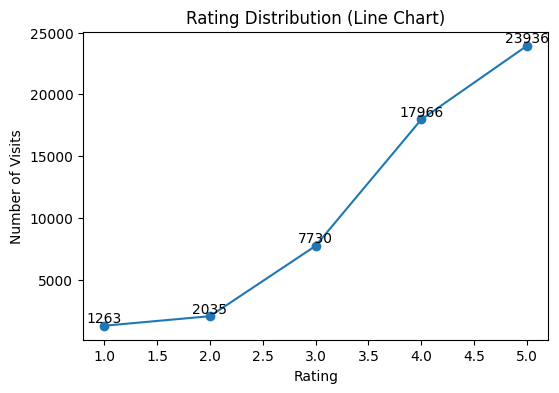

In [45]:
# Count ratings and sort by rating value
rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.plot(rating_counts.index, rating_counts.values, marker='o')

plt.xlabel('Rating')
plt.ylabel('Number of Visits')
plt.title('Rating Distribution (Line Chart)')

# Add value labels on points
for x, y in zip(rating_counts.index, rating_counts.values):
    plt.text(x, y, y, ha='center', va='bottom')

plt.show()


* Each point shows how many times a rating was given

* The line helps compare which ratings are most common

* Labels make the chart easy to read without guessing numbers

## 2. Most Popular Visit Modes

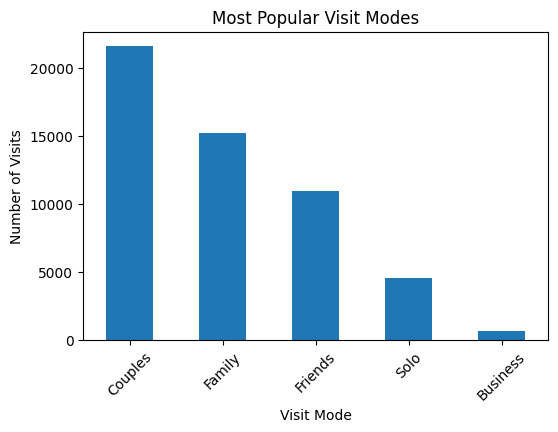

In [46]:
visit_mode_counts = df['VisitModeName'].value_counts()

plt.figure(figsize=(6,4))
visit_mode_counts.plot(kind='bar')
plt.xlabel('Visit Mode')
plt.ylabel('Number of Visits')
plt.title('Most Popular Visit Modes')
plt.xticks(rotation=45)

plt.show()


## 3. Visits by Year

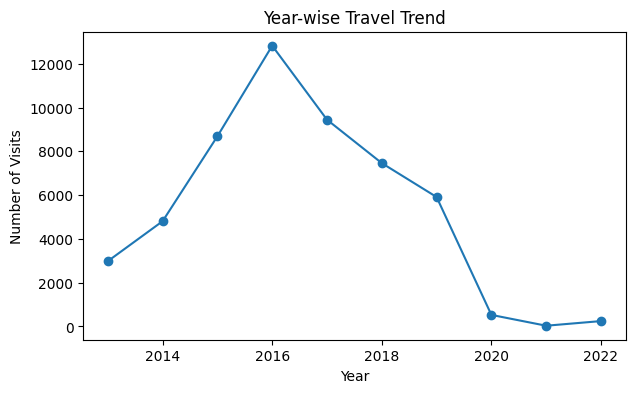

In [47]:

yearly_visits = df['VisitYear'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(yearly_visits.index, yearly_visits.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Visits')
plt.title('Year-wise Travel Trend')
plt.show()


* Insight: Shows whether tourism is increasing or decreasing over years.

## 4. Top 10 Most Visited Cities

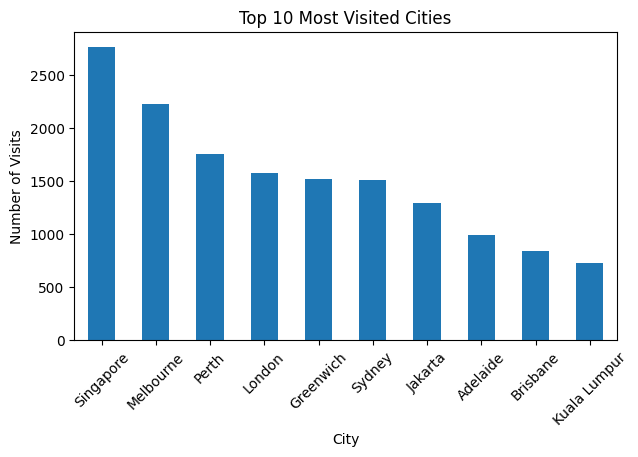

In [48]:
top_cities = df['CityName'].value_counts().head(10)

plt.figure(figsize=(7,4))
top_cities.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Number of Visits')
plt.title('Top 10 Most Visited Cities')
plt.xticks(rotation=45)
plt.show()


* Insight: Identifies high-demand tourist cities.

## 5. Visit By Continent

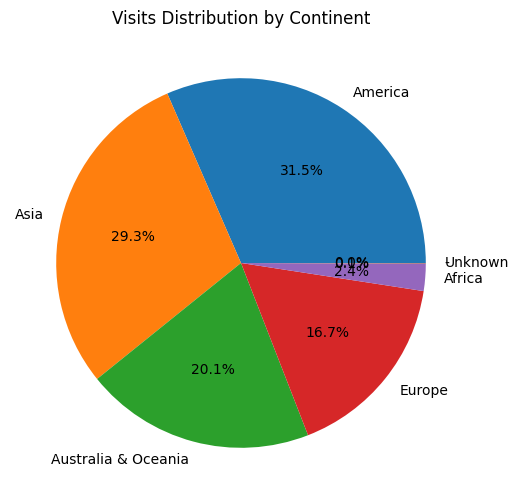

In [49]:
continent_counts = df['Continent'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(continent_counts,  labels=continent_counts.index,autopct='%1.1f%%')
plt.title('Visits Distribution by Continent')
plt.show()


* Insight: Shows which continent attracts the most tourists.

## 6. Monthly Travel Pattern

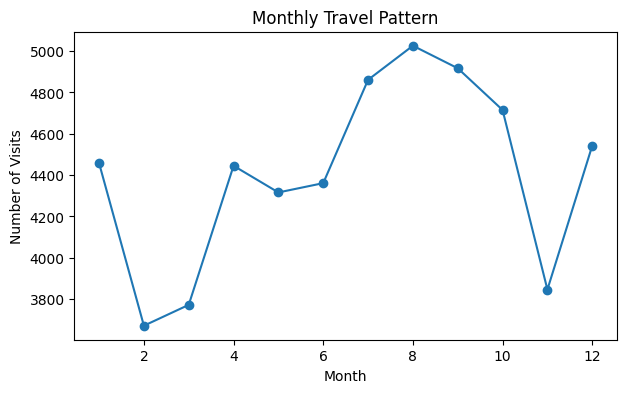

In [50]:
monthly_visits = df['VisitMonth'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(monthly_visits.index, monthly_visits.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.title('Monthly Travel Pattern')
plt.show()


* Insight: Helps identify peak travel months.

## 7. Top Attraction Type

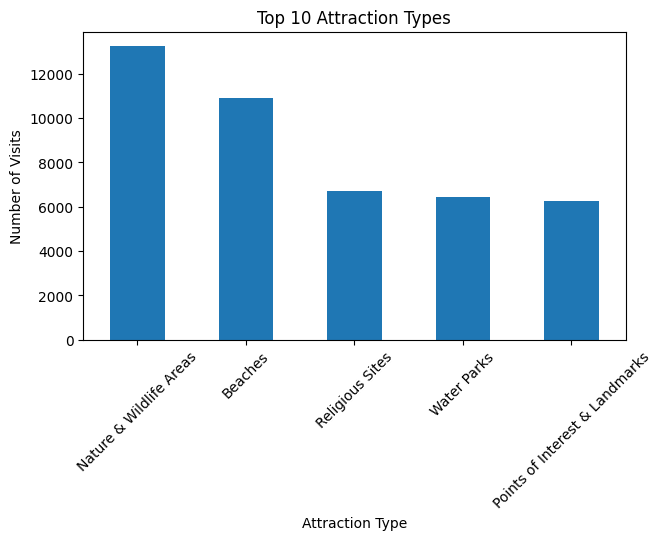

In [51]:
top_attraction_types = df['AttractionType'].value_counts().head(5)

plt.figure(figsize=(7,4))
top_attraction_types.plot(kind='bar')
plt.xlabel('Attraction Type')
plt.ylabel('Number of Visits')
plt.title('Top 10 Attraction Types')
plt.xticks(rotation=45)
plt.show()


* Insight: It shows whether people prefer beaches, parks, monuments, etc

## 8. Correlation Heatmap of Numerical Features

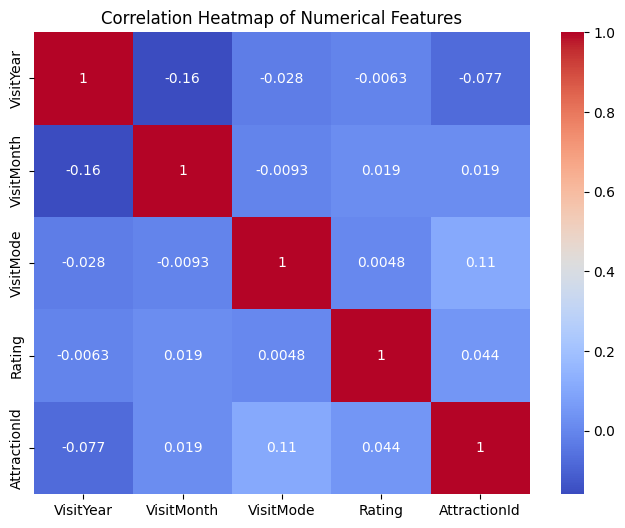

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'VisitYear', 'VisitMonth', 'VisitMode',
    'Rating', 'AttractionId'
]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


* Darker colors mean stronger relationships

* Helps identify which factors influence ratings or visits

## 9. Visit Mode vs Rating

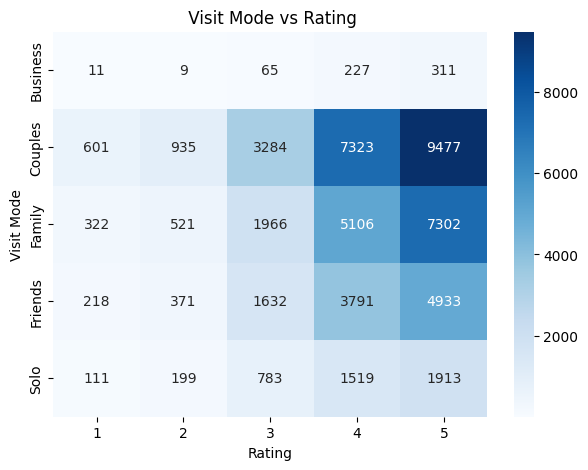

In [53]:
visit_rating = pd.crosstab(
    df['VisitModeName'],
    df['Rating']
)

plt.figure(figsize=(7,5))
sns.heatmap(visit_rating, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Rating')
plt.ylabel('Visit Mode')
plt.title(' Visit Mode vs Rating')
plt.show()


## 10. Pair Plot

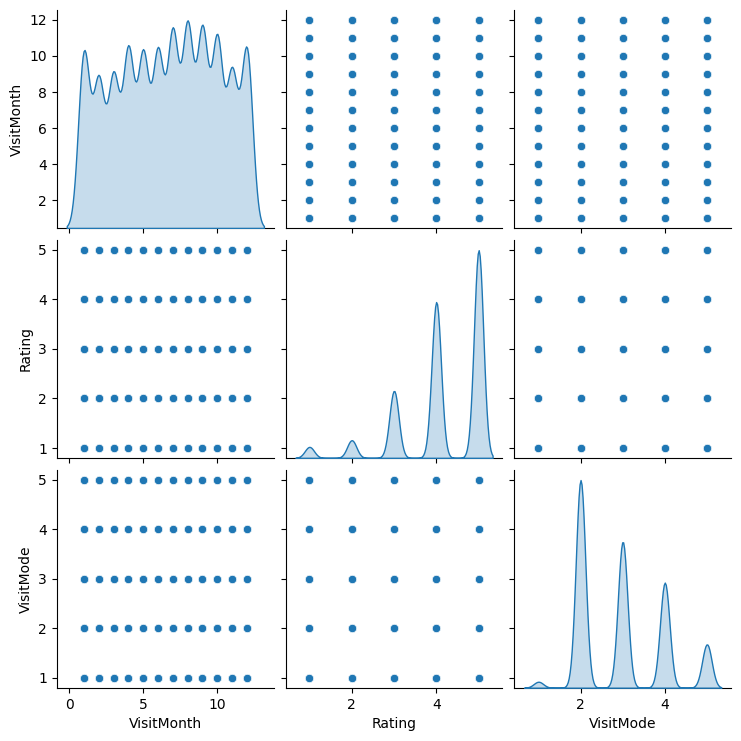

In [54]:
pair_cols = ['VisitMonth','Rating','VisitMode']

sns.pairplot(df[pair_cols],diag_kind='kde')
plt.show()


# Step-5.  Feature Engineering
Feature Engineering is the process of creating new meaningful features and transforming existing ones to improve model performance. In this step, raw data is converted into a format that machine learning models can understand better. This includes encoding categorical variables, extracting useful information from existing columns, and removing unnecessary or redundant features. Proper feature engineering helps the model learn patterns more effectively and improves prediction accuracy.
In this project, feature engineering is done to:

* Improve rating prediction (regression)

* Improve visit mode prediction (classification)

* Enable personalized attraction recommendations

In [55]:
# Step 1: Removing columns
drop_cols = ['AttractionCityId']

df = df.drop(columns=drop_cols, errors='ignore')

# Step 2: Target Identification
# Regression Target
target_regression = 'Rating'

# Classification Target
target_classification = 'VisitModeName'

# Step 3: Date & Seasonal Feature Creation
# Create VisitSeason from VisitMonth
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Festive'

df['VisitSeason'] = df['VisitMonth'].apply(get_season)

# Step 4: User Behavior Features
# Average rating given by each user
df['User_Avg_Rating'] = df.groupby('UserId')['Rating'].transform('mean')

# Total visits by each user
df['User_Total_Visits'] = df.groupby('UserId')['AttractionId'].transform('count')

# Most preferred visit mode by user
df['User_Preferred_VisitMode'] = (
    df.groupby('UserId')['VisitModeName']
      .transform(lambda x: x.mode()[0])
)

# Most visited attraction type by user
df['User_Favorite_AttractionType'] = (
    df.groupby('UserId')['AttractionType']
      .transform(lambda x: x.mode()[0])
)

# Step 5: Attraction Popularity Features
# Average rating per attraction
df['Attraction_Avg_Rating'] = df.groupby('AttractionId')['Rating'].transform('mean')

# Total visits per attraction
df['Attraction_Visit_Count'] = df.groupby('AttractionId')['UserId'].transform('count')

# City popularity (number of visits per city)
df['City_Visit_Count'] = df.groupby('CityId')['UserId'].transform('count')

# Step 6: Feature Scaling
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'User_Avg_Rating',
    'User_Total_Visits',
    'Attraction_Avg_Rating',
    'Attraction_Visit_Count',
    'City_Visit_Count'
]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Step 7: Feature Selection
drop_cols = [
    'TransactionId',
    'AttractionAddress'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Step 8: Final Check
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   UserId                        52930 non-null  int64  
 1   VisitYear                     52930 non-null  int64  
 2   VisitMonth                    52930 non-null  int64  
 3   VisitMode                     52930 non-null  int64  
 4   AttractionId                  52930 non-null  int64  
 5   Rating                        52930 non-null  int64  
 6   CityId                        52930 non-null  int64  
 7   AttractionTypeId              52930 non-null  Int64  
 8   Attraction                    52930 non-null  object 
 9   AttractionType                52930 non-null  object 
 10  CityName                      52930 non-null  object 
 11  CountryId                     52930 non-null  int64  
 12  Country                       52930 non-null  object 
 13  R

,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,CityId,AttractionTypeId,Attraction,AttractionType,...,Continent,VisitModeName,VisitSeason,User_Avg_Rating,User_Total_Visits,User_Preferred_VisitMode,User_Favorite_AttractionType,Attraction_Avg_Rating,Attraction_Visit_Count,City_Visit_Count
0,70456,2022,10,2,640,5,4341,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,...,Australia & Oceania,Couples,Festive,1.016439,-0.484152,Couples,Nature & Wildlife Areas,0.373335,1.61316,-0.659439
1,7567,2022,10,4,640,5,464,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,...,America,Friends,Festive,1.016439,-0.484152,Friends,Nature & Wildlife Areas,0.373335,1.61316,-0.694630
2,79069,2022,10,3,640,5,774,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,...,America,Family,Festive,1.016439,-0.484152,Family,Nature & Wildlife Areas,0.373335,1.61316,-0.704338
3,31019,2022,10,3,640,3,583,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,...,America,Family,Festive,-1.397043,-0.195413,Family,Nature & Wildlife Areas,0.373335,1.61316,-0.610900
4,43611,2022,10,2,640,3,1396,63,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,...,America,Couples,Festive,-1.397043,0.093326,Couples,Nature & Wildlife Areas,0.373335,1.61316,-0.460427


* After feature engineering, I verified the dataset to ensure there were no missing values, incorrect data types, or inconsistencies. All numerical and categorical features were properly formatted, and new features such as season, user average rating, and attraction popularity were successfully created. The dataset is now clean, optimized, and ready for modeling.”

# Step-6. ML - Modeling

#  1.   Random Forest Regressor

In [56]:
# Target
y = df['Rating']

# Drop useless columns
X = df.drop(columns=[
    'Rating',
    'UserId',
    'TransactionId',
    'AttractionAddress'
], errors='ignore')

# one - hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(
    n_estimators=60,
    random_state=25,
    n_jobs=-1
)

rf_regressor.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [58]:
# ===============================
# Model Evaluation
# ===============================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = rf_regressor.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(" Random Forest Regression Performance")
print("----------------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")


 Random Forest Regression Performance
----------------------------------------
MAE  : 0.2773
MSE  : 0.2978
RMSE : 0.5457
R2   : 0.6838


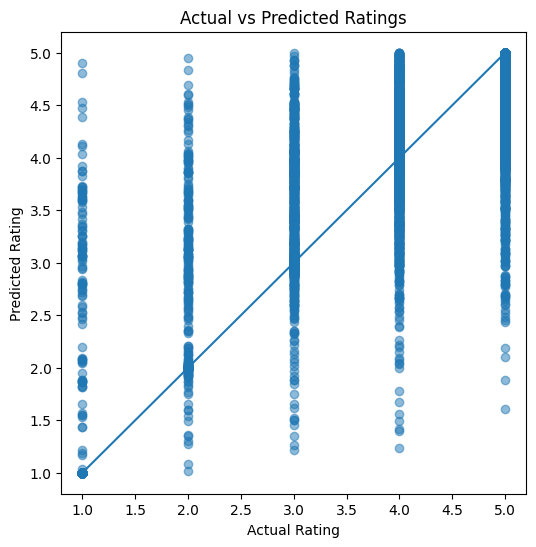

In [59]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.show()

In [60]:
import joblib

joblib.dump(rf_regressor, "rf_regressor.pkl")
joblib.dump(X_encoded.columns, "regression_feature_columns.pkl")


['regression_feature_columns.pkl']

# 3. Classification
The goal of this classification model is to predict the Visit Mode of a tourist (such as Solo, Family, Friends, Couple, etc.) based on various features like attraction type, region, continent, visit history, and user behavior patterns.

This helps in understanding tourist behavior and improving tourism planning, marketing strategies, and personalized recommendations.

## Random Forest Classifier

In [63]:

# ----------------------------
# Prepare Data
# ----------------------------

df_cls = df.copy()

target = "VisitModeName"

selected_features = [
    "UserId",
    "AttractionId",
    "AttractionType"
]

X = df_cls[selected_features]
y = df_cls[target]

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Identify categorical & numeric
categorical_cols = ["AttractionType"]
numeric_cols = ["UserId", "AttractionId"]

# ----------------------------
# Preprocessing
# ----------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# ----------------------------
# Pipeline
# ----------------------------
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# ----------------------------
# Train-Test Split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Train
model.fit(X_train, y_train)

print("Visit Mode Model Trained Successfully ✅")

# ----------------------------
# Evaluation
# ----------------------------

y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=le_target.classes_,
    zero_division=0
))

print("Macro F1 Score:",
      f1_score(y_test, y_pred, average='macro'))


# ----------------------------
# Save Model
# ----------------------------

joblib.dump(model, "visitmode_pipeline.pkl")
joblib.dump(le_target, "visitmode_label_encoder.pkl")

print("Model Saved Successfully ✅")


Visit Mode Model Trained Successfully ✅
              precision    recall  f1-score   support

    Business       0.12      0.32      0.18       125
     Couples       0.50      0.62      0.55      4324
      Family       0.52      0.36      0.43      3043
     Friends       0.36      0.26      0.30      2189
        Solo       0.20      0.27      0.23       905

    accuracy                           0.44     10586
   macro avg       0.34      0.37      0.34     10586
weighted avg       0.45      0.44      0.43     10586

Macro F1 Score: 0.3369469290073057
Model Saved Successfully ✅


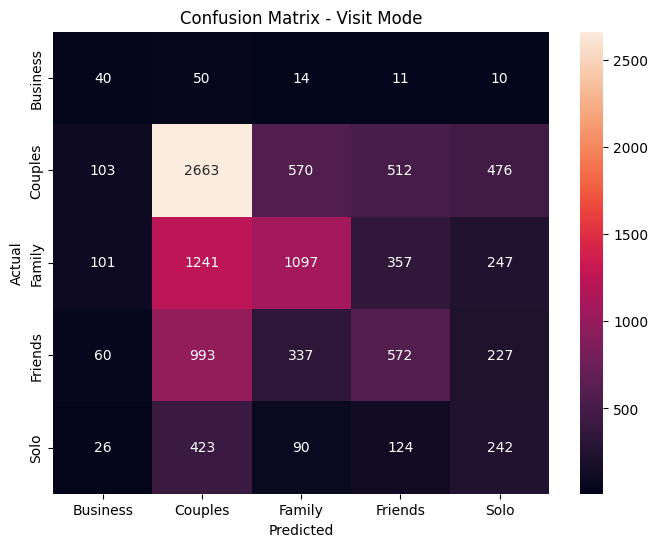

In [64]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Visit Mode")
plt.show()


# 4. RECOMMENDATION SYSTEM
* The goal of the recommendation system is to suggest tourist attractions that a user is most likely to enjoy based on their past visit history, ratings, and preferences.

* This system uses Collaborative Filtering to find users with similar preferences and recommends attractions liked by similar users.

* Additionally, Content-Based Filtering is used to recommend attractions similar in type and location to those previously visited by the user.

#### Create User-Attraction Matrix

In [65]:

user_item_matrix = df.pivot_table(
    index='UserId',
    columns='Attraction',
    values='Rating'
)

user_item_matrix = user_item_matrix.fillna(0)

print("User-Item Matrix Shape:", user_item_matrix.shape)


User-Item Matrix Shape: (33530, 30)


* Each row = User
* Each column = Attraction
* Each value = Rating given by user

In [66]:
from sklearn.neighbors import NearestNeighbors

user_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=6,
    n_jobs=-1
)

user_knn.fit(user_item_matrix)


,n_neighbors,6
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,-1


#### Recommendation Function

In [67]:
def recommend_attractions(user_id, top_n=5):

    if user_id not in user_item_matrix.index:
        return []

    user_vector = user_item_matrix.loc[[user_id]]

    distances, indices = user_knn.kneighbors(user_vector)

    similar_users = user_item_matrix.index[indices.flatten()[1:]]

    similar_users_ratings = user_item_matrix.loc[similar_users]

    mean_ratings = similar_users_ratings.mean(axis=0)

    user_rated = user_item_matrix.loc[user_id]
    mean_ratings = mean_ratings[user_rated == 0]

    recommendations = mean_ratings.sort_values(ascending=False).head(top_n)

    return list(recommendations.index)


### CONTENT-BASED FILTERING

In [68]:
attraction_features = df[
    ['Attraction', 'AttractionType', 'CityName', 'Country']
].drop_duplicates(subset='Attraction').reset_index(drop=True)


In [69]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded_features = encoder.fit_transform(
    attraction_features[['AttractionType', 'CityName', 'Country']]
)

encoded_df = pd.DataFrame(
    encoded_features,
    index=attraction_features['Attraction']
)


In [70]:
item_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

item_knn.fit(encoded_df)


,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [71]:
def recommend_similar_attractions(attraction_name, top_n=5):

    if attraction_name not in encoded_df.index:
        return []

    attraction_vector = encoded_df.loc[[attraction_name]]

    distances, indices = item_knn.kneighbors(
        attraction_vector,
        n_neighbors=top_n + 1
    )

    similar_indices = indices.flatten()[1:]

    recommendations = encoded_df.index[similar_indices]

    return list(recommendations)


### HYBRID RECOMMENDATION

In [72]:
def hybrid_recommendation(user_id, attraction_name, top_n=5):

    collab_list = recommend_attractions(user_id, top_n)
    content_list = recommend_similar_attractions(attraction_name, top_n)

    combined = collab_list + content_list

    # remove duplicates while preserving order
    seen = set()
    hybrid_list = []

    for item in combined:
        if item not in seen:
            seen.add(item)
            hybrid_list.append(item)

    return hybrid_list[:top_n]


In [73]:
# Evaluation
import numpy as np

def precision_recall_at_k(user_item_matrix, k=5):

    precisions = []
    recalls = []

    for user_id in user_item_matrix.index[:500]:

        actual_items = user_item_matrix.loc[user_id]
        actual_items = set(actual_items[actual_items > 0].index)

        if len(actual_items) == 0:
            continue

        # take one rated attraction for content input
        seed_item = list(actual_items)[0]

        recommended_items = hybrid_recommendation(
            user_id,
            seed_item,
            top_n=k
        )

        recommended_items = set(recommended_items)

        hits = len(actual_items & recommended_items)

        precisions.append(hits / k)
        recalls.append(hits / len(actual_items))

    print("Precision@K:", round(np.mean(precisions), 4))
    print("Recall@K:", round(np.mean(recalls), 4))


# Step -7.  MODEL DEPLOYMENT

In [74]:
model.feature_names_in_

array(['UserId', 'AttractionId', 'AttractionType'], dtype=object)

#### Save ML Model

In [75]:

visit_label_encoder = joblib.load("visitmode_label_encoder.pkl")

# 🔹 Classification Model
visit_model = joblib.load("visitmode_pipeline.pkl")
le_target = joblib.load("visitmode_label_encoder.pkl")


## Streamlit Dashboard


In [76]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [77]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Tourism Analytics Dashboard", layout="wide")
st.title("🌍 Tourism Analytics & Recommendation Dashboard")

# ==============================
# Load Models & Data
# ==============================

# 🔹 Regression Model (Make sure this file exists)
rating_model = joblib.load("rf_regressor.pkl")
reg_feature_columns = joblib.load("regression_feature_columns.pkl")

# 🔹 Classification Model

visit_model = joblib.load("visitmode_pipeline.pkl")
le_target = joblib.load("visitmode_label_encoder.pkl")

# 🔹 Recommendation System
user_knn = joblib.load("user_knn.pkl")
item_knn = joblib.load("item_knn.pkl")

user_item_matrix = pd.read_pickle("user_item_matrix.pkl")
encoded_df = pd.read_pickle("encoded_df.pkl")

# ==============================
# Sidebar Navigation
# ==============================

menu = st.sidebar.selectbox(
    "Select Module",
    ["Rating Prediction", "Visit Mode Prediction", "Hybrid Recommendation"]
)

# ============================================================
# 1️⃣ RATING PREDICTION
# ============================================================

if menu == "Rating Prediction":

    st.header("⭐ Predict Attraction Rating")

    # Let user select attraction
    attraction_columns = [
        col for col in reg_feature_columns 
        if col.startswith("Attraction_")
    ]

    attraction_name = st.selectbox("Select Attraction", attraction_columns)

    attraction_visit_count = st.number_input("Attraction Visit Count", min_value=0)
    city_visit_count = st.number_input("City Visit Count", min_value=0)

    if st.button("Predict Rating"):

        # Create full feature frame
        input_data = pd.DataFrame(
            np.zeros((1, len(reg_feature_columns))),
            columns=reg_feature_columns
        )

        # Fill numeric fields if they exist
        if "Attraction_Visit_Count" in input_data.columns:
            input_data["Attraction_Visit_Count"] = attraction_visit_count

        if "City_Visit_Count" in input_data.columns:
            input_data["City_Visit_Count"] = city_visit_count

        # Set selected attraction dummy = 1
        if attraction_name in input_data.columns:
            input_data[attraction_name] = 1

        prediction = rating_model.predict(input_data)[0]

        st.success(f"Predicted Rating: {round(prediction,2)}")

# ============================================================
# 2️⃣ VISIT MODE CLASSIFICATION
# ============================================================

elif menu == "Visit Mode Prediction":

    st.header("🎯 Predict Visit Mode")

    user_id = st.number_input("User ID", min_value=1)
    attraction_id = st.number_input("Attraction ID", min_value=1)

    attraction_type = st.selectbox(
        "Select Attraction Type",
        ["Beach", "Mountain", "Temple", "Museum", "Park", "Wildlife"]
    )

    if st.button("Predict Visit Mode"):

        input_data = pd.DataFrame({
            "UserId": [user_id],
            "AttractionId": [attraction_id],
            "AttractionType": [attraction_type]
        })

        prediction_encoded = visit_model.predict(input_data)[0]

        prediction = le_target.inverse_transform(
            [prediction_encoded]
        )[0]

        st.success(f"Predicted Visit Mode: {prediction}")

# ============================================================
# 3️⃣ HYBRID RECOMMENDATION
# ============================================================

elif menu == "Hybrid Recommendation":

    st.header("🌟 Hybrid Recommendation System")

    user_id = st.number_input("Enter User ID", min_value=1)

    attraction_list = list(encoded_df.index)
    attraction_name = st.selectbox("Select Attraction", attraction_list)

    top_n = st.slider("Number of Recommendations", 1, 10, 5)

    def recommend_attractions(user_id, top_n=5):

        if user_id not in user_item_matrix.index:
            return []

        user_vector = user_item_matrix.loc[[user_id]]
        distances, indices = user_knn.kneighbors(user_vector)

        similar_users = user_item_matrix.index[indices.flatten()[1:]]

        similar_users_ratings = user_item_matrix.loc[similar_users]
        mean_ratings = similar_users_ratings.mean(axis=0)

        user_rated = user_item_matrix.loc[user_id]
        mean_ratings = mean_ratings[user_rated == 0]

        recommendations = mean_ratings.sort_values(ascending=False).head(top_n)

        return list(recommendations.index)

    def recommend_similar_attractions(attraction_name, top_n=5):

        if attraction_name not in encoded_df.index:
            return []

        attraction_vector = encoded_df.loc[[attraction_name]]

        distances, indices = item_knn.kneighbors(
            attraction_vector,
            n_neighbors=top_n + 1
        )

        similar_indices = indices.flatten()[1:]

        return list(encoded_df.index[similar_indices])

    def hybrid_recommendation(user_id, attraction_name, top_n=5):

        collab = recommend_attractions(user_id, top_n)
        content = recommend_similar_attractions(attraction_name, top_n)

        combined = collab + content

        seen = set()
        final = []

        for item in combined:
            if item not in seen:
                seen.add(item)
                final.append(item)

        return final[:top_n]

    if st.button("Get Recommendations"):

        recommendations = hybrid_recommendation(
            user_id,
            attraction_name,
            top_n
        )

        if recommendations:
            st.success("Recommended Attractions:")
            for rec in recommendations:
                st.write("👉", rec)
        else:
            st.warning("No recommendations found.")


2026-02-17 22:13:40.349 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 22:13:40.352 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 22:13:41.376 
  command:

    streamlit run C:\Users\kushw\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-02-17 22:13:41.378 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 22:13:41.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 22:13:42.350 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 22:13:42.353 Thread 'MainThread': missing ScriptRunContext! This warning can b

In [78]:
# Save this script as app.py
streamlit_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Tourism Analytics Dashboard", layout="wide")
st.title("🌍 Tourism Analytics & Recommendation Dashboard")

# ==============================
# Load Models & Data
# ==============================

# 🔹 Regression Model (Make sure this file exists)
rating_model = joblib.load("rf_regressor.pkl")
reg_feature_columns = joblib.load("regression_feature_columns.pkl")

# 🔹 Classification Model
visit_model = joblib.load("visitmode_pipeline.pkl")
le_target = joblib.load("visitmode_label_encoder.pkl")
# 🔹 Recommendation System
user_knn = joblib.load("user_knn.pkl")
item_knn = joblib.load("item_knn.pkl")

user_item_matrix = pd.read_pickle("user_item_matrix.pkl")
encoded_df = pd.read_pickle("encoded_df.pkl")

# ==============================
# Sidebar Navigation
# ==============================

menu = st.sidebar.selectbox(
    "Select Module",
    ["Rating Prediction", "Visit Mode Prediction", "Hybrid Recommendation"]
)

# ============================================================
# 1️⃣ RATING PREDICTION
# ============================================================

if menu == "Rating Prediction":

    st.header("⭐ Predict Attraction Rating")

    # Let user select attraction
    attraction_columns = [
        col for col in reg_feature_columns 
        if col.startswith("Attraction_")
    ]

    attraction_name = st.selectbox("Select Attraction", attraction_columns)

    attraction_visit_count = st.number_input("Attraction Visit Count", min_value=0)
    city_visit_count = st.number_input("City Visit Count", min_value=0)

    if st.button("Predict Rating"):

        # Create full feature frame
        input_data = pd.DataFrame(
            np.zeros((1, len(reg_feature_columns))),
            columns=reg_feature_columns
        )

        # Fill numeric fields if they exist
        if "Attraction_Visit_Count" in input_data.columns:
            input_data["Attraction_Visit_Count"] = attraction_visit_count

        if "City_Visit_Count" in input_data.columns:
            input_data["City_Visit_Count"] = city_visit_count

        # Set selected attraction dummy = 1
        if attraction_name in input_data.columns:
            input_data[attraction_name] = 1

        prediction = rating_model.predict(input_data)[0]

        st.success(f"Predicted Rating: {round(prediction,2)}")

# ============================================================
# 2️⃣ VISIT MODE CLASSIFICATION
# ============================================================

elif menu == "Visit Mode Prediction":

    st.header("🎯 Predict Visit Mode")

    user_id = st.number_input("User ID", min_value=1)
    attraction_id = st.number_input("Attraction ID", min_value=1)

    attraction_type = st.selectbox(
        "Select Attraction Type",
        ["Beach", "Mountain", "Temple", "Museum", "Park", "Wildlife"]
    )

    if st.button("Predict Visit Mode"):

        input_data = pd.DataFrame({
            "UserId": [user_id],
            "AttractionId": [attraction_id],
            "AttractionType": [attraction_type]
        })

        prediction_encoded = visit_model.predict(input_data)[0]

        prediction = le_target.inverse_transform(
            [prediction_encoded]
        )[0]

        st.success(f"Predicted Visit Mode: {prediction}")


# ============================================================
# 3️⃣ HYBRID RECOMMENDATION
# ============================================================

elif menu == "Hybrid Recommendation":

    st.header("🌟 Hybrid Recommendation System")

    user_id = st.number_input("Enter User ID", min_value=1)

    attraction_list = list(encoded_df.index)
    attraction_name = st.selectbox("Select Attraction", attraction_list)

    top_n = st.slider("Number of Recommendations", 1, 10, 5)

    def recommend_attractions(user_id, top_n=5):

        if user_id not in user_item_matrix.index:
            return []

        user_vector = user_item_matrix.loc[[user_id]]
        distances, indices = user_knn.kneighbors(user_vector)

        similar_users = user_item_matrix.index[indices.flatten()[1:]]

        similar_users_ratings = user_item_matrix.loc[similar_users]
        mean_ratings = similar_users_ratings.mean(axis=0)

        user_rated = user_item_matrix.loc[user_id]
        mean_ratings = mean_ratings[user_rated == 0]

        recommendations = mean_ratings.sort_values(ascending=False).head(top_n)

        return list(recommendations.index)

    def recommend_similar_attractions(attraction_name, top_n=5):

        if attraction_name not in encoded_df.index:
            return []

        attraction_vector = encoded_df.loc[[attraction_name]]

        distances, indices = item_knn.kneighbors(
            attraction_vector,
            n_neighbors=top_n + 1
        )

        similar_indices = indices.flatten()[1:]

        return list(encoded_df.index[similar_indices])

    def hybrid_recommendation(user_id, attraction_name, top_n=5):

        collab = recommend_attractions(user_id, top_n)
        content = recommend_similar_attractions(attraction_name, top_n)

        combined = collab + content

        seen = set()
        final = []

        for item in combined:
            if item not in seen:
                seen.add(item)
                final.append(item)

        return final[:top_n]

    if st.button("Get Recommendations"):

        recommendations = hybrid_recommendation(
            user_id,
            attraction_name,
            top_n
        )

        if recommendations:
            st.success("Recommended Attractions:")
            for rec in recommendations:
                st.write("👉", rec)
        else:
            st.warning("No recommendations found.")

"""

# Write to app.py
with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("Streamlit app saved as app.py ✅")


Streamlit app saved as app.py ✅
